In [1]:
%pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-_txu4s6u
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-_txu4s6u
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.4 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369547 sha256=30f9b5e2becc92077259c6ebd9a175434d877dcffe9490bec617c140f07acc68
  Stored in directory: /tmp/pip-ephem-wheel-cache-elyi931k/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
import clip
from torchvision.datasets import STL10
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm

import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

from scipy.linalg import orthogonal_procrustes

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


##  Zero-Shot Classification on STL-10


In [4]:
# Using ViT-B/32, a standard robust vision transformer model in CLIP
model, preprocess = clip.load("ViT-B/32", device=device)
model.eval()

100%|████████████████████████████████████████| 338M/338M [00:02<00:00, 161MiB/s]


CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): Sequential(
        (0): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): QuickGELU()
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
        (1): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          

In [5]:
# --- Load Dataset ---
# Using the test split (8,000 images) for evaluation
dataset = STL10(root="./data", split="test", download=True, transform=preprocess)
dataloader = DataLoader(dataset, batch_size=256, shuffle=False)

classes = dataset.classes
print(f"STL-10 Classes: {classes}")

100%|██████████| 2.64G/2.64G [04:04<00:00, 10.8MB/s] 


STL-10 Classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


In [6]:
# --- Define Prompts & Extract Text Features ---
prompts = {
    "i. Plain labels": [f"{c}" for c in classes],
    "ii. Prompted text": [f"a photo of a {c}" for c in classes],
    "iii. Descriptive variants": [f"a centered, high quality photo of a {c}, showcasing its distinct features" for c in classes]
}

text_features_dict = {}
with torch.no_grad():
    for prompt_type, text_list in prompts.items():
        # Tokenize and encode text
        text_tokens = clip.tokenize(text_list).to(device)
        text_features = model.encode_text(text_tokens)
        
        # Normalize text features
        text_features /= text_features.norm(dim=-1, keepdim=True)
        text_features_dict[prompt_type] = text_features

In [7]:
# --- Extract Image Features & Evaluate ---
correct_counts = {prompt_type: 0 for prompt_type in prompts.keys()}
total = 0

print("Extracting image features and computing accuracy...")
with torch.no_grad():
    for images, labels in tqdm(dataloader, desc="Processing Batches"):
        images, labels = images.to(device), labels.to(device)
        
        # Encode and normalize image features
        image_features = model.encode_image(images)
        image_features /= image_features.norm(dim=-1, keepdim=True)
        
        # Compare against all three prompt types simultaneously
        for prompt_type, text_features in text_features_dict.items():
            # Calculate cosine similarity and predict highest match
            similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)
            predictions = similarity.argmax(dim=-1)
            
            # Tally correct predictions
            correct_counts[prompt_type] += (predictions == labels).sum().item()
        
        total += labels.size(0)

Extracting image features and computing accuracy...


Processing Batches:   0%|          | 0/32 [00:00<?, ?it/s]

In [8]:
# --- Results ---
print("\n--- Zero-Shot Classification Accuracy on STL-10 ---")
for prompt_type, correct in correct_counts.items():
    accuracy = (correct / total) * 100
    print(f"{prompt_type}: {accuracy:.2f}%")


--- Zero-Shot Classification Accuracy on STL-10 ---
i. Plain labels: 96.26%
ii. Prompted text: 97.36%
iii. Descriptive variants: 96.26%


## Exploring the Modality Gap

Modality Gap: All image embeddings clump together in one region of the space, and all text embeddings clump together in a completely separate region. They are aligned in direction (relative to their own modalities), but separated by a distinct physical distance.

In [9]:
# --- Sample 100 Images and Labels ---
# We use a new dataloader with shuffle=True to get a random mix of classes
sample_loader = DataLoader(dataset, batch_size=100, shuffle=True)
images, labels = next(iter(sample_loader))
images = images.to(device)

print(f"Sampled {len(images)} images for visualization.")

Sampled 100 images for visualization.


In [10]:
# --- Extract Embeddings ---
with torch.no_grad():
    # Extract Image Embeddings
    image_features = model.encode_image(images)
    image_features /= image_features.norm(dim=-1, keepdim=True)
    
    # Create corresponding text prompts (using the "ii" template from earlier)
    text_descriptions = [f"a photo of a {classes[label]}" for label in labels]
    text_tokens = clip.tokenize(text_descriptions).to(device)
    
    # Extract Text Embeddings
    text_features = model.encode_text(text_tokens)
    text_features /= text_features.norm(dim=-1, keepdim=True)

    # Convert to numpy for scikit-learn
    image_features_np = image_features.cpu().numpy()
    text_features_np = text_features.cpu().numpy()

In [11]:
# --- Dimensionality Reduction (t-SNE) ---
# We must stack them together BEFORE running t-SNE
# If we run t-SNE on them separately, they will be projected into completely different spaces
all_features = np.vstack((image_features_np, text_features_np))

print("Running t-SNE dimensionality reduction (this takes a few seconds)...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
all_features_2d = tsne.fit_transform(all_features)

# Split them back apart after they share the same 2D projection space
image_features_2d = all_features_2d[:100]
text_features_2d = all_features_2d[100:]

Running t-SNE dimensionality reduction (this takes a few seconds)...


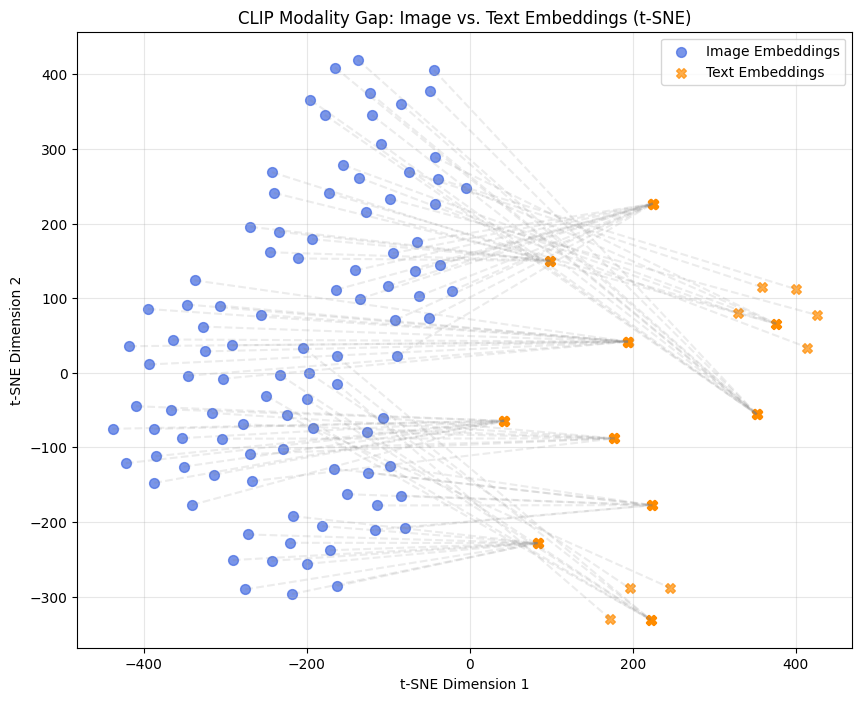

In [12]:
# --- Visualization ---
plt.figure(figsize=(10, 8))

# Plot Image Embeddings (Circles)
plt.scatter(image_features_2d[:, 0], image_features_2d[:, 1], 
            c='royalblue', alpha=0.7, label='Image Embeddings', marker='o', s=50)

# Plot Text Embeddings (X's)
plt.scatter(text_features_2d[:, 0], text_features_2d[:, 1], 
            c='darkorange', alpha=0.7, label='Text Embeddings', marker='X', s=50)

# Optional: Draw faint lines connecting the matching image-text pairs
for i in range(100):
    plt.plot([image_features_2d[i, 0], text_features_2d[i, 0]], 
             [image_features_2d[i, 1], text_features_2d[i, 1]], 
             c='gray', alpha=0.15, linestyle='--')

plt.title("CLIP Modality Gap: Image vs. Text Embeddings (t-SNE)")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Bridging the Modality Gap

In [13]:
# --- Learn the Rotation Matrix (R) ---
print("Extracting training features to learn Procrustes Transform...")
# Load a batch from the train split to learn R (to avoid data leakage on the test set)
train_dataset = STL10(root="./data", split="train", download=True, transform=preprocess)
train_loader = DataLoader(train_dataset, batch_size=1000, shuffle=True)
images_train, labels_train = next(iter(train_loader))
images_train = images_train.to(device)

with torch.no_grad():
    # X: Image features
    X_train = model.encode_image(images_train)
    X_train /= X_train.norm(dim=-1, keepdim=True)
    
    # Y: Corresponding text features
    prompts_train = [f"a photo of a {classes[label]}" for label in labels_train]
    tokens_train = clip.tokenize(prompts_train).to(device)
    Y_train = model.encode_text(tokens_train)
    Y_train /= Y_train.norm(dim=-1, keepdim=True)
    
    X_train_np = X_train.cpu().numpy()
    Y_train_np = Y_train.cpu().numpy()

# Solve for R that minimizes ||XR - Y||_F
R, scale = orthogonal_procrustes(X_train_np, Y_train_np)
R_tensor = torch.tensor(R, dtype=torch.float32, device=device)
print("Rotation matrix R learned successfully.")

Extracting training features to learn Procrustes Transform...
Rotation matrix R learned successfully.


Running t-SNE on aligned features...


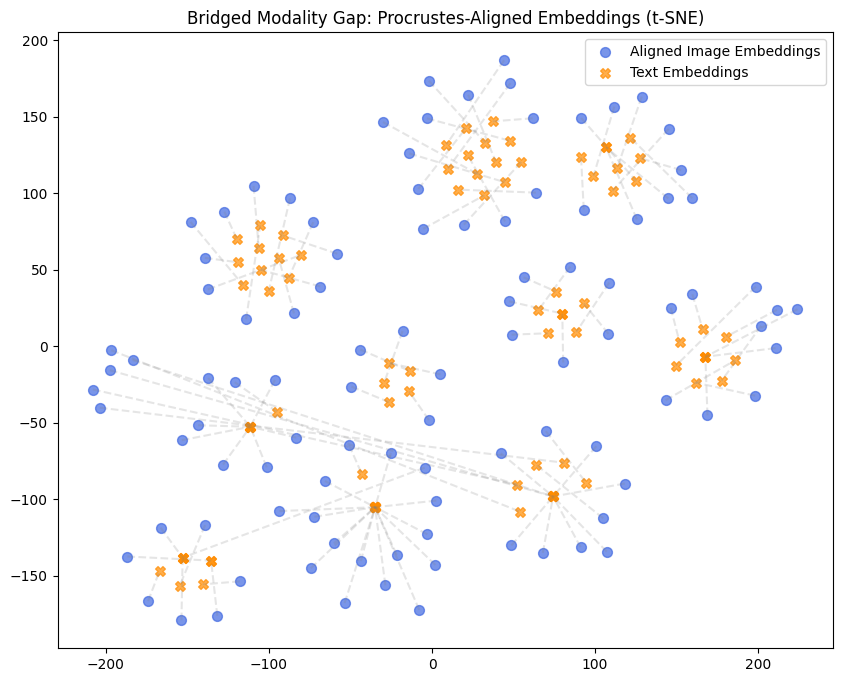

In [14]:
# --- Visualize the Aligned Embeddings ---
# Sample 100 test images for visualization
sample_loader = DataLoader(dataset, batch_size=100, shuffle=True) # dataset from Part 1
images_vis, labels_vis = next(iter(sample_loader))
images_vis = images_vis.to(device)

with torch.no_grad():
    X_vis = model.encode_image(images_vis)
    X_vis /= X_vis.norm(dim=-1, keepdim=True)
    
    # Apply the rotation transform: X_aligned = X @ R
    X_vis_aligned = X_vis @ R_tensor.to(X_vis.dtype)
    
    prompts_vis = [f"a photo of a {classes[l]}" for l in labels_vis]
    tokens_vis = clip.tokenize(prompts_vis).to(device)
    Y_vis = model.encode_text(tokens_vis)
    Y_vis /= Y_vis.norm(dim=-1, keepdim=True)

all_features_aligned = np.vstack((X_vis_aligned.cpu().numpy(), Y_vis.cpu().numpy()))
print("Running t-SNE on aligned features...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
all_2d_aligned = tsne.fit_transform(all_features_aligned)

image_features_2d = all_2d_aligned[:100]
text_features_2d = all_2d_aligned[100:]

plt.figure(figsize=(10, 8))
plt.scatter(image_features_2d[:, 0], image_features_2d[:, 1], 
            c='royalblue', alpha=0.7, label='Aligned Image Embeddings', marker='o', s=50)
plt.scatter(text_features_2d[:, 0], text_features_2d[:, 1], 
            c='darkorange', alpha=0.7, label='Text Embeddings', marker='X', s=50)

for i in range(100):
    plt.plot([image_features_2d[i, 0], text_features_2d[i, 0]], 
             [image_features_2d[i, 1], text_features_2d[i, 1]], 
             c='gray', alpha=0.2, linestyle='--')

plt.title("Bridged Modality Gap: Procrustes-Aligned Embeddings (t-SNE)")
plt.legend()
plt.show()

In [15]:
# --- Recompute Classification Accuracy ---
correct_counts_aligned = {prompt_type: 0 for prompt_type in prompts.keys()}
total = 0

print("Recomputing classification accuracy with aligned embeddings...")
with torch.no_grad():
    for images, labels in tqdm(dataloader, desc="Evaluating Aligned Test Set"):
        images, labels = images.to(device), labels.to(device)
        
        image_features = model.encode_image(images)
        image_features /= image_features.norm(dim=-1, keepdim=True)
        
        # APPLY ALIGNMENT to the entire test set
        image_features_aligned = image_features @ R_tensor.to(image_features.dtype)
        
        for prompt_type, text_features in text_features_dict.items(): # From Part 1
            similarity = (100.0 * image_features_aligned @ text_features.T).softmax(dim=-1)
            predictions = similarity.argmax(dim=-1)
            correct_counts_aligned[prompt_type] += (predictions == labels).sum().item()
        
        total += labels.size(0)

print("\n--- Procrustes-Aligned Zero-Shot Accuracy on STL-10 ---")
for prompt_type, correct in correct_counts_aligned.items():
    accuracy = (correct / total) * 100
    print(f"{prompt_type}: {accuracy:.2f}%")

Recomputing classification accuracy with aligned embeddings...


Evaluating Aligned Test Set:   0%|          | 0/32 [00:00<?, ?it/s]


--- Procrustes-Aligned Zero-Shot Accuracy on STL-10 ---
i. Plain labels: 96.70%
ii. Prompted text: 97.74%
iii. Descriptive variants: 97.59%


## Additional Diagrams

Generating Similarity Heatmap...


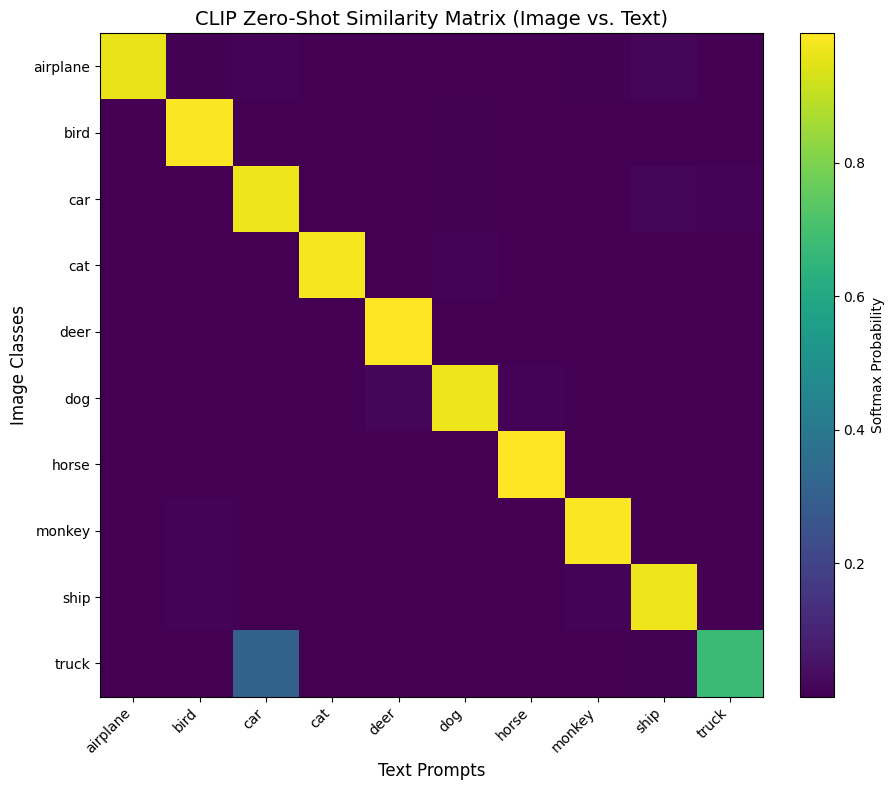


Generating Top-5 Confidence Charts...


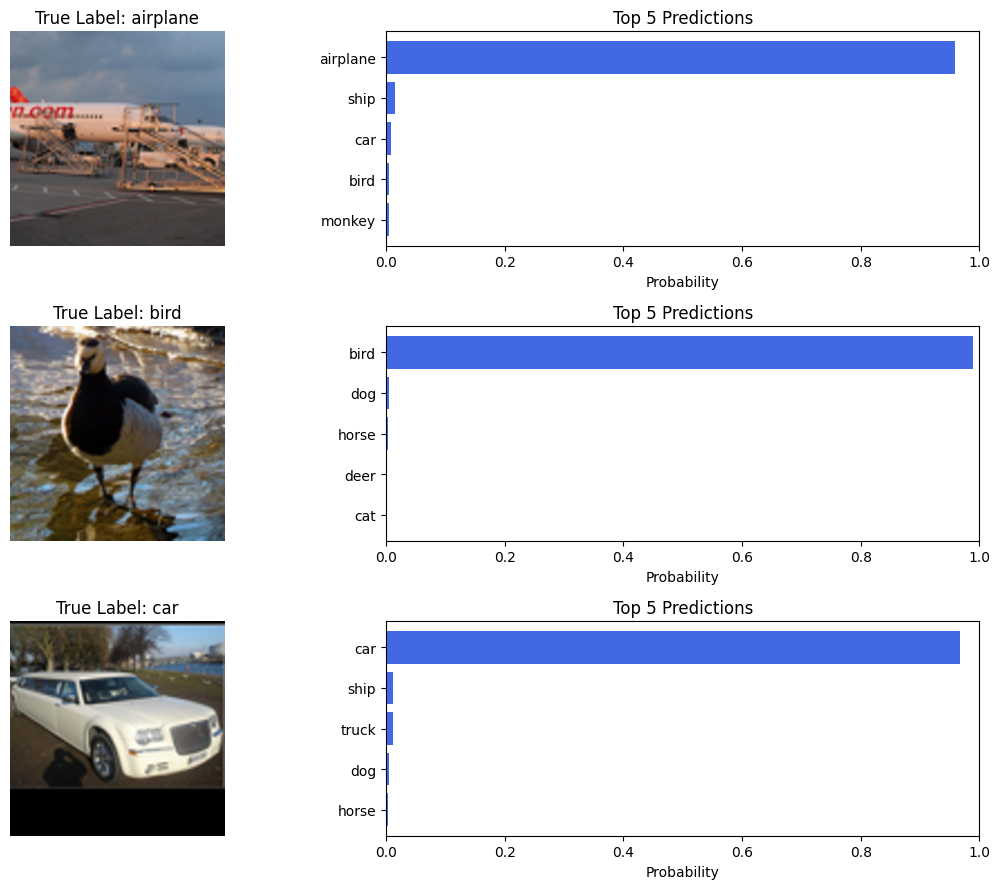


Generating Modality Gap Histogram...


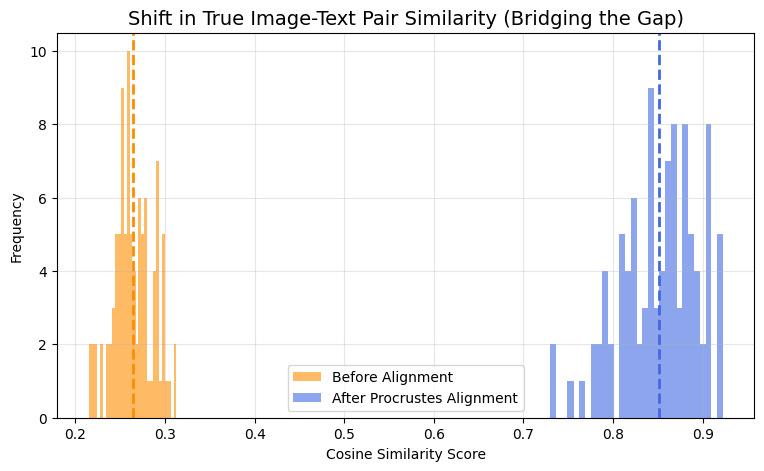

In [17]:
model.eval()
with torch.no_grad():
    # --- Setup: Find exactly one image per class from our test set ---
    unique_images_dict = {}
    
    # Grab one image per class
    for img, label in dataset:
        if label not in unique_images_dict:
            unique_images_dict[label] = img
        if len(unique_images_dict) == 10:
            break
    unique_images = [unique_images_dict[i] for i in range(10)]
    unique_labels = [i for i in range(10)]
            
    # Stack into tensors
    img_tensor = torch.stack(unique_images).to(device)
    
    # Get text prompts for all 10 classes in strict order
    class_prompts = [f"a photo of a {c}" for c in classes]
    text_tokens = clip.tokenize(class_prompts).to(device)
    
    # Extract features
    img_feats = model.encode_image(img_tensor)
    img_feats /= img_feats.norm(dim=-1, keepdim=True)
    
    text_feats = model.encode_text(text_tokens)
    text_feats /= text_feats.norm(dim=-1, keepdim=True)
    
    # Calculate similarity matrix (10x10)
    sim_matrix = (100.0 * img_feats @ text_feats.T).softmax(dim=-1).cpu().numpy()

    # --- Diagram 1: Cosine Similarity Heatmap ---
    print("Generating Similarity Heatmap...")
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(sim_matrix, cmap='viridis')
    
    # Label ticks (now they perfectly align!)
    ax.set_xticks(np.arange(len(classes)))
    ax.set_yticks(np.arange(len(classes)))
    ax.set_xticklabels(classes, rotation=45, ha="right", fontsize=10)
    ax.set_yticklabels(classes, fontsize=10)
    
    ax.set_title("CLIP Zero-Shot Similarity Matrix (Image vs. Text)", fontsize=14)
    ax.set_xlabel("Text Prompts", fontsize=12)
    ax.set_ylabel("Image Classes", fontsize=12)
    plt.colorbar(im, fraction=0.046, pad=0.04, label="Softmax Probability")
    plt.tight_layout()
    plt.show()

    # --- Top-5 Prediction Confidence ---
    print("\nGenerating Top-5 Confidence Charts...")
    num_samples = 3
    fig, axes = plt.subplots(num_samples, 2, figsize=(12, 3 * num_samples))
    
    for i in range(num_samples):
        # Image
        img_np = unique_images[i].permute(1, 2, 0).numpy()
        # Denormalize image for plotting (CLIP preprocessing normalizes it)
        mean = np.array([0.48145466, 0.4578275, 0.40821073])
        std = np.array([0.26862954, 0.26130258, 0.27577711])
        img_np = std * img_np + mean
        img_np = np.clip(img_np, 0, 1)
        
        axes[i, 0].imshow(img_np)
        true_class = classes[unique_labels[i]]
        axes[i, 0].set_title(f"True Label: {true_class}")
        axes[i, 0].axis('off')
        
        # Bar Chart
        probs = sim_matrix[i]
        top5_idx = np.argsort(probs)[-5:][::-1]
        top5_probs = probs[top5_idx]
        top5_labels = [classes[idx] for idx in top5_idx]
        
        y_pos = np.arange(len(top5_labels))
        axes[i, 1].barh(y_pos, top5_probs, color='royalblue')
        axes[i, 1].set_yticks(y_pos)
        axes[i, 1].set_yticklabels(top5_labels)
        axes[i, 1].invert_yaxis()  # Highest probability at the top
        axes[i, 1].set_xlabel("Probability")
        axes[i, 1].set_xlim(0, 1)
        axes[i, 1].set_title("Top 5 Predictions")
        
    plt.tight_layout()
    plt.show()

    # --- Quantitative Gap Closure (Similarity Histogram) ---
    print("\nGenerating Modality Gap Histogram...")
    # Calculate raw cosine similarity (dot product of normalized vectors)
    # This requires X_vis, X_vis_aligned, and Y_vis from your earlier Part 3 code
    
    # We will compute the similarity between each image and its *correct* text prompt
    sim_before = (X_vis * Y_vis).sum(dim=-1).cpu().numpy()
    sim_after = (X_vis_aligned * Y_vis).sum(dim=-1).cpu().numpy()
    
    plt.figure(figsize=(9, 5))
    plt.hist(sim_before, bins=30, alpha=0.6, color='darkorange', label="Before Alignment")
    plt.hist(sim_after, bins=30, alpha=0.6, color='royalblue', label="After Procrustes Alignment")
    
    plt.axvline(sim_before.mean(), color='darkorange', linestyle='dashed', linewidth=2)
    plt.axvline(sim_after.mean(), color='royalblue', linestyle='dashed', linewidth=2)
    
    plt.title("Shift in True Image-Text Pair Similarity (Bridging the Gap)", fontsize=14)
    plt.xlabel("Cosine Similarity Score")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()